# tema 2

In [6]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import os
os.chdir('/home/jerry/Documents/master/Master/Machine learning - PART IV/Data')
pd.set_option('display.max_columns', None) ## paraquitar los puntitos q no dejan ver todo bien

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.feature_selection import SelectKBest, chi2

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('breast_cancer_data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [8]:
## segun vemos columnas nos sobran. las quitamos:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)
df.head(9)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720


In [9]:
## quitamos tmb duplicados
df.drop_duplicates(inplace=True) ## no es bueno que haya duplicados ya que sino, si metemos el mismo registro x veces el modelo aprende tantas veces como resgistro haya iguales

In [10]:
## vemos los tipos
df.dtypes
# vemos que son todos numericos menos uno q es de tipo str (q es la target)

diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [11]:
df.describe()
## aqui nso dice todos los valores maximos, minimas, cuartiles,...
## esto nos sirve para ver si son saltos graduales si hay datos q son nulos pero que los relennan con 0 por ejemplo oa lgo
##ppor ejemplo en area_mean es el valor muy alto el dato maximo cuando los cuartiles no tanto

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
df.corr( numeric_only=True) ## el numeric es para quitar las variables str (en este caso la variabel objetivo)
# con esto vemos la correlacion entre todos los campos

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,0.000111,0.164174,0.039830,-0.090170,0.401964,0.559837,0.446630,0.341198,0.345007,0.688132,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [13]:
# vemos variable categorica
df.groupby('diagnosis').size()
# para ver proporcion

diagnosis
B    357
M    212
dtype: int64

## ahora vamos con los plots

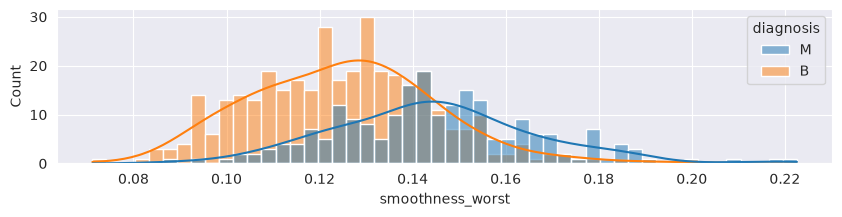

In [14]:
plt.figure(figsize=(10,2))
# sns.histplot(data=df, x='smoothness_worst',kde=True)
sns.histplot(data=df, x='smoothness_worst',kde=True, bins=50,hue='diagnosis') # para separar por la variable categorica esto interesa mucho. esto se debe a que cuanto menores sean los valores mayor es la probabilidad de que el diagnosis sea b
plt.show()

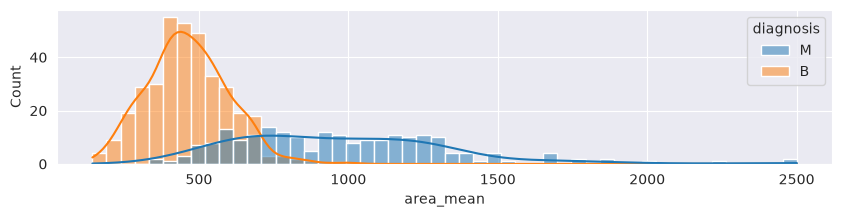

In [15]:
# vemos igual otra variable
plt.figure(figsize=(10,2))
sns.histplot(data=df, x='area_mean',kde=True, bins=50,hue='diagnosis') # como podemos ver cuanto mas grande sean los tumores tienden a ser malignos, meintras que si son mas chicos, tienen a ser beningos
plt.show()

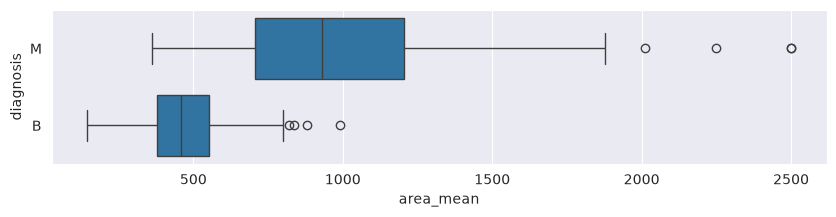

In [16]:
# vemos otros tipos de plots, como por ejemplo el de cajas
plt.figure(figsize=(10,2))
sns.boxplot(data=df, x='area_mean', y='diagnosis') # con esot lo vemos con la variable objetivo
plt.show()
# segun vemos para los beningnos casi el 80% de los casos es menor que el valor de unos 750, meintras que para los malignos, a aprtir del 750, es superior

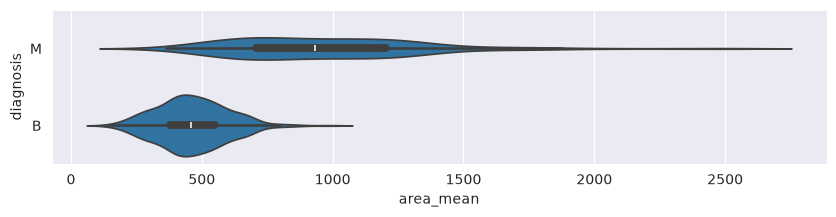

In [17]:
# vemos otros tipos de plots
plt.figure(figsize=(10,2))
sns.violinplot(data=df, x='area_mean', y='diagnosis') # con esot lo vemos con la variable objetivo
plt.show()

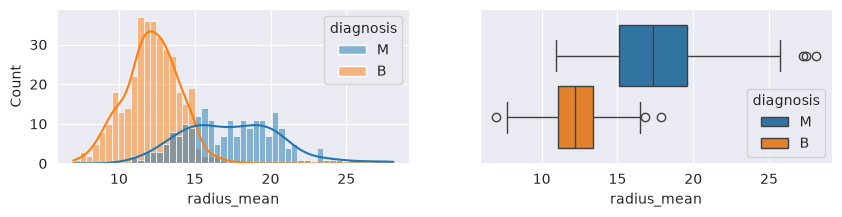

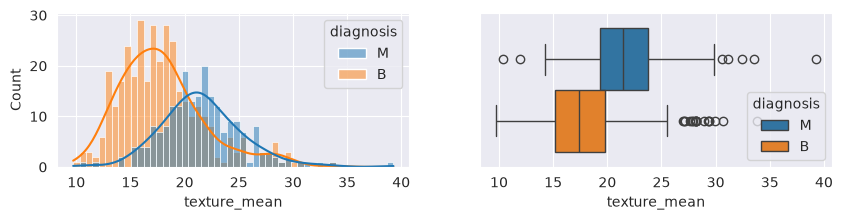

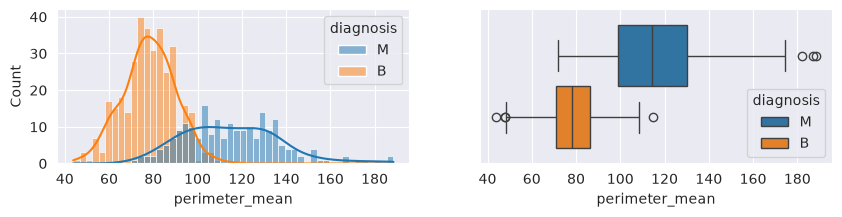

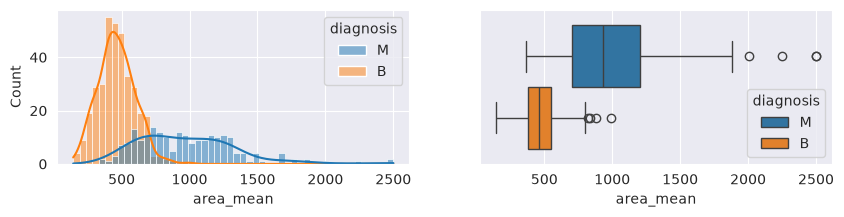

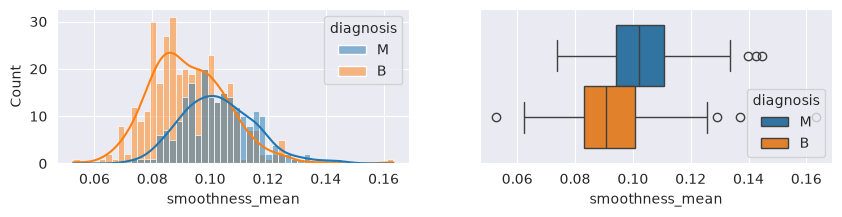

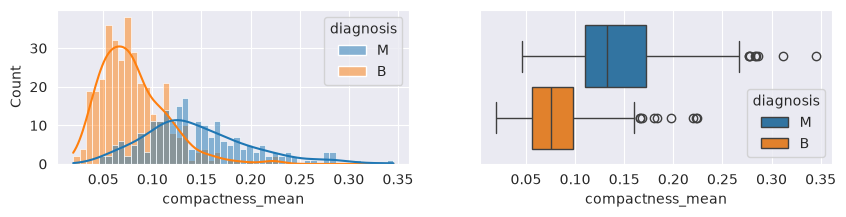

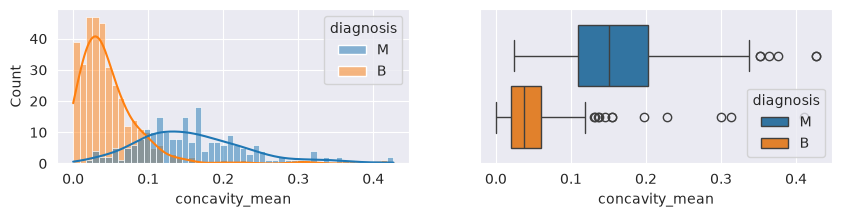

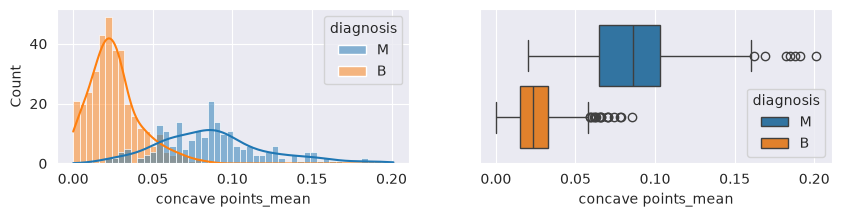

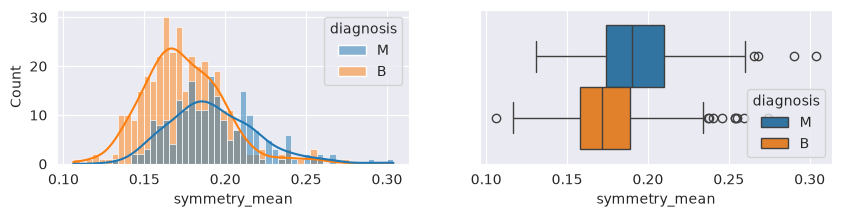

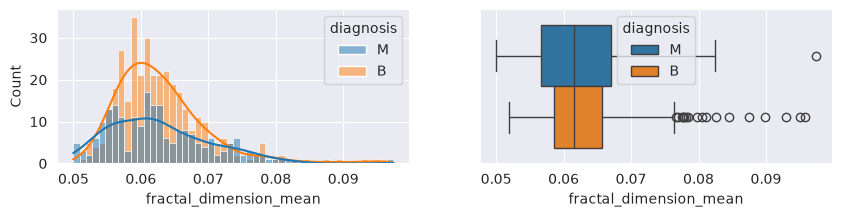

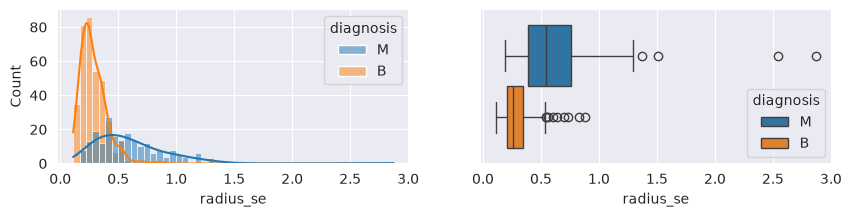

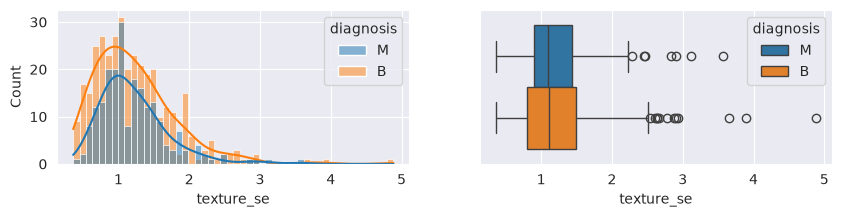

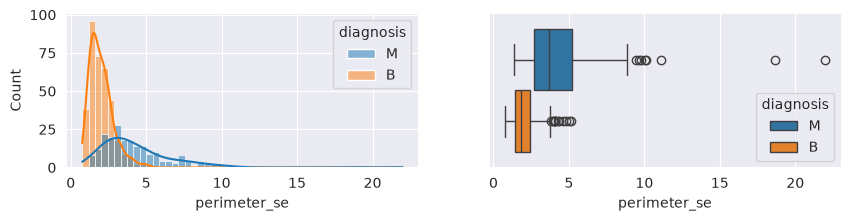

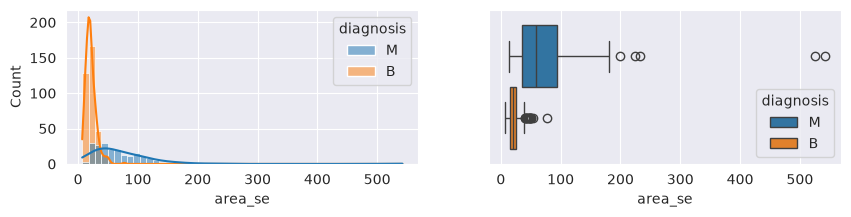

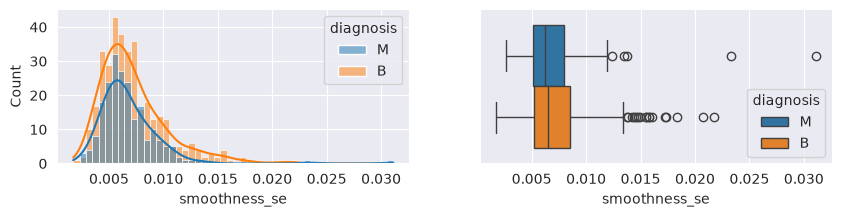

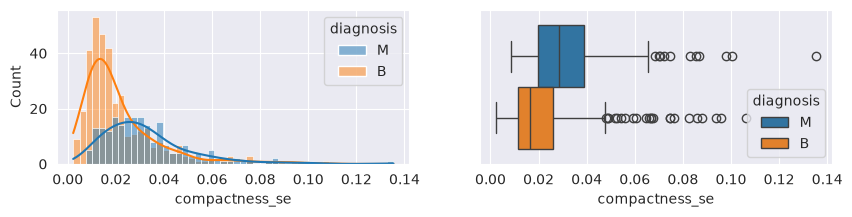

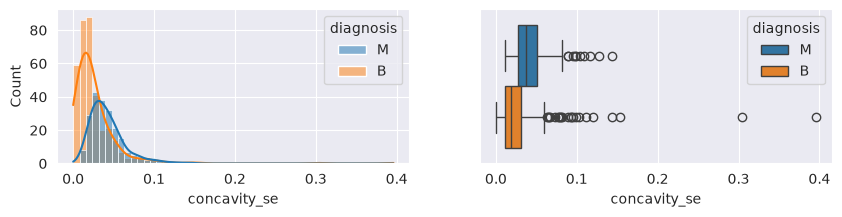

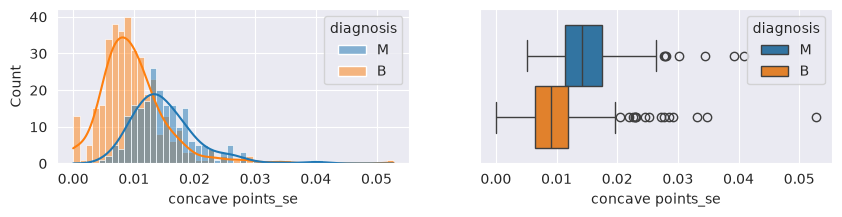

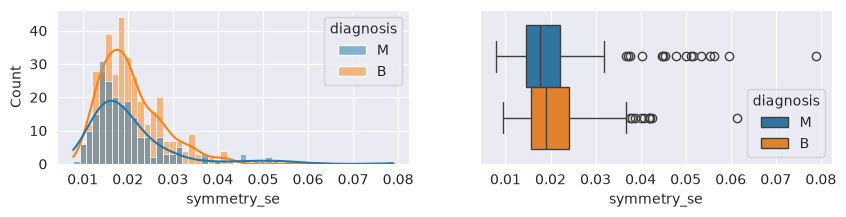

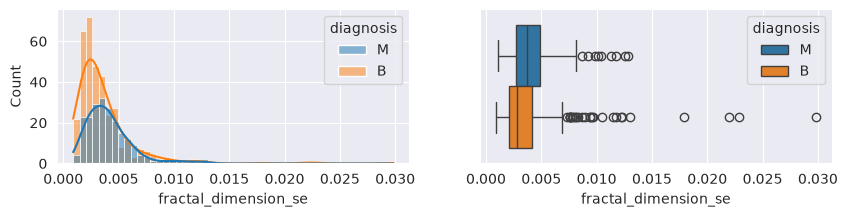

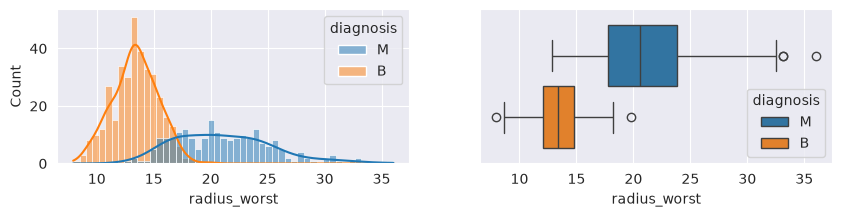

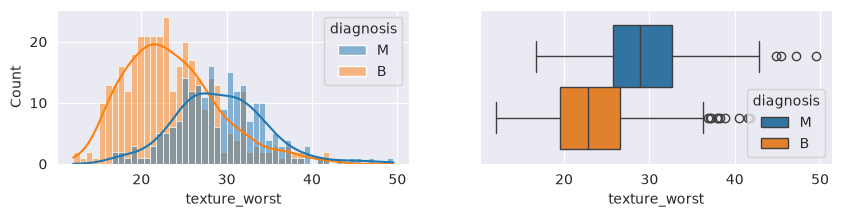

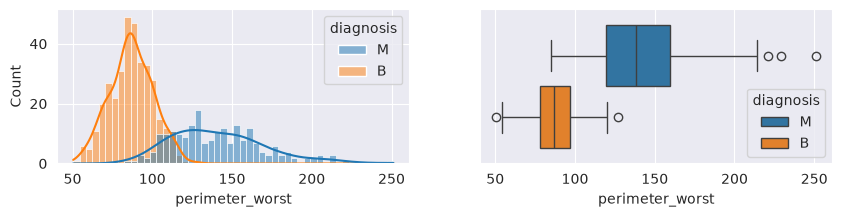

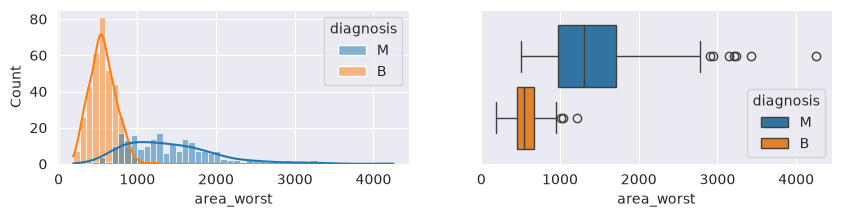

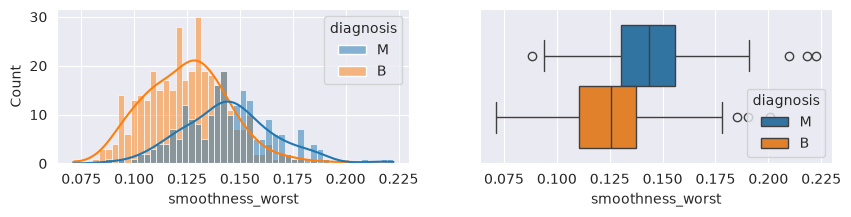

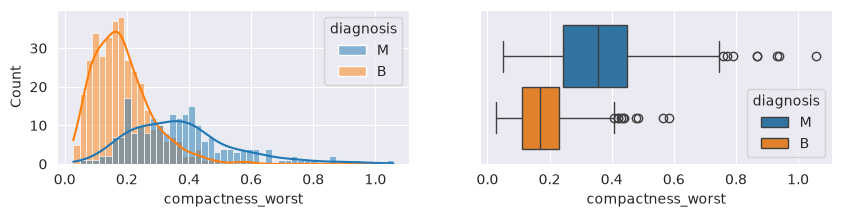

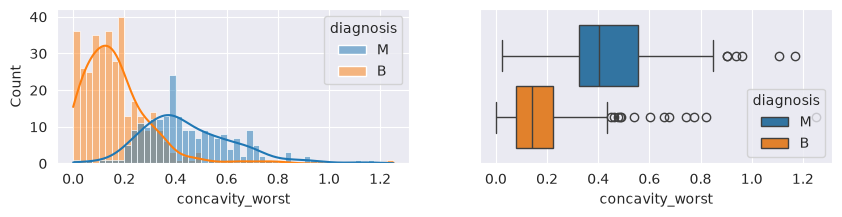

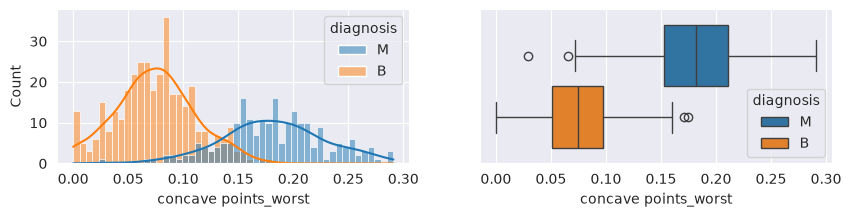

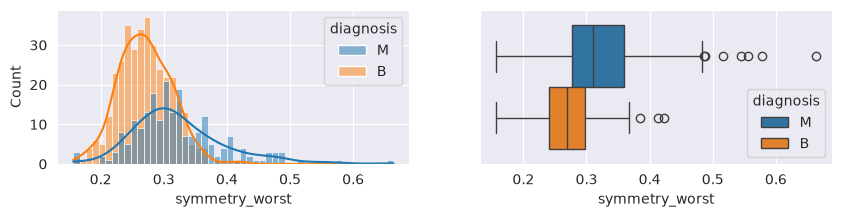

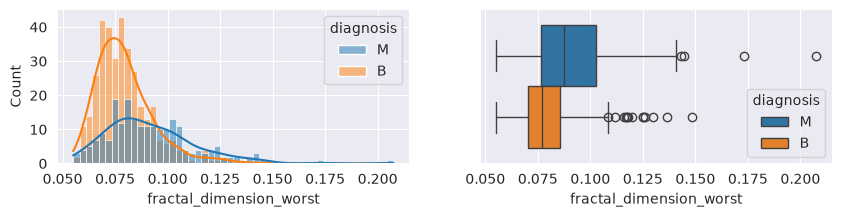

In [18]:
cols_names = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

for col in cols_names:
    plt.figure(figsize=(10,2))
    plt.subplot(1,2,1) # 1 fila, 2 columnas, en la primera posicion
    sns.histplot(data=df,x=col,kde=True, bins=50, hue='diagnosis')
    plt.subplot(1,2,2) # 1 fila, 2 columnas, en la segunda posicion
    sns.boxplot(data=df,x=col, hue='diagnosis')
    plt.show()

## esto nos sirve para ver todas los campos que tenemos comprarlos con la variable objetivo con las gráficas que hemos visto antes

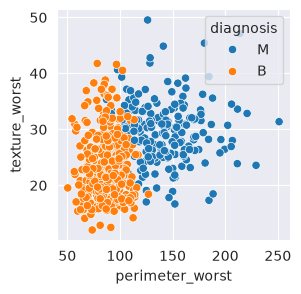

In [19]:
plt.figure(figsize=(3,3))
# sns.scatterplot(data=df,x='perimeter_worst',y='texture_worst')
sns.scatterplot(data=df,x='perimeter_worst',y='texture_worst', hue='diagnosis')

plt.show()

## como vemos aqui si tomases de 1 en una dimension, la de texture_worst, estan bastante bien intermezclados, sin embargo en perimeter worst, es una buena variable predictora ya que tiene un thresholds.

# aqui vemos que puede ayudar la de texture_wrost ya que nos puede ayudar con dos dimensiones, poniendo una linea un poco mas diagonal

<Figure size 300x300 with 0 Axes>

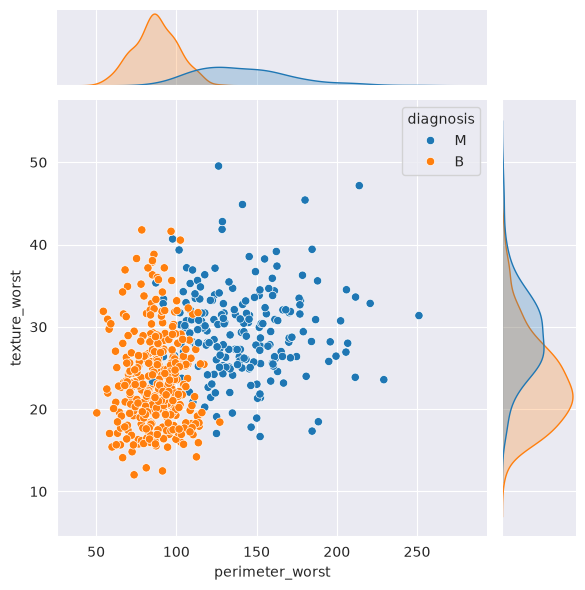

In [20]:
plt.figure(figsize=(3,3))
sns.jointplot(data=df,x='perimeter_worst',y='texture_worst', hue='diagnosis') # este es el scater junto con una conexion
plt.show()

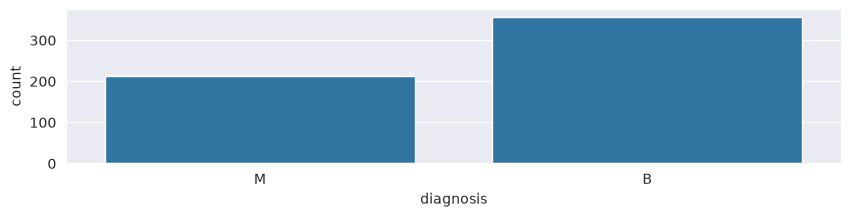

In [21]:
## para las categoricas:::: el counplot es lo mas sencillo
plt.figure(figsize=(10,2))
sns.countplot(data=df, x='diagnosis')
plt.show()

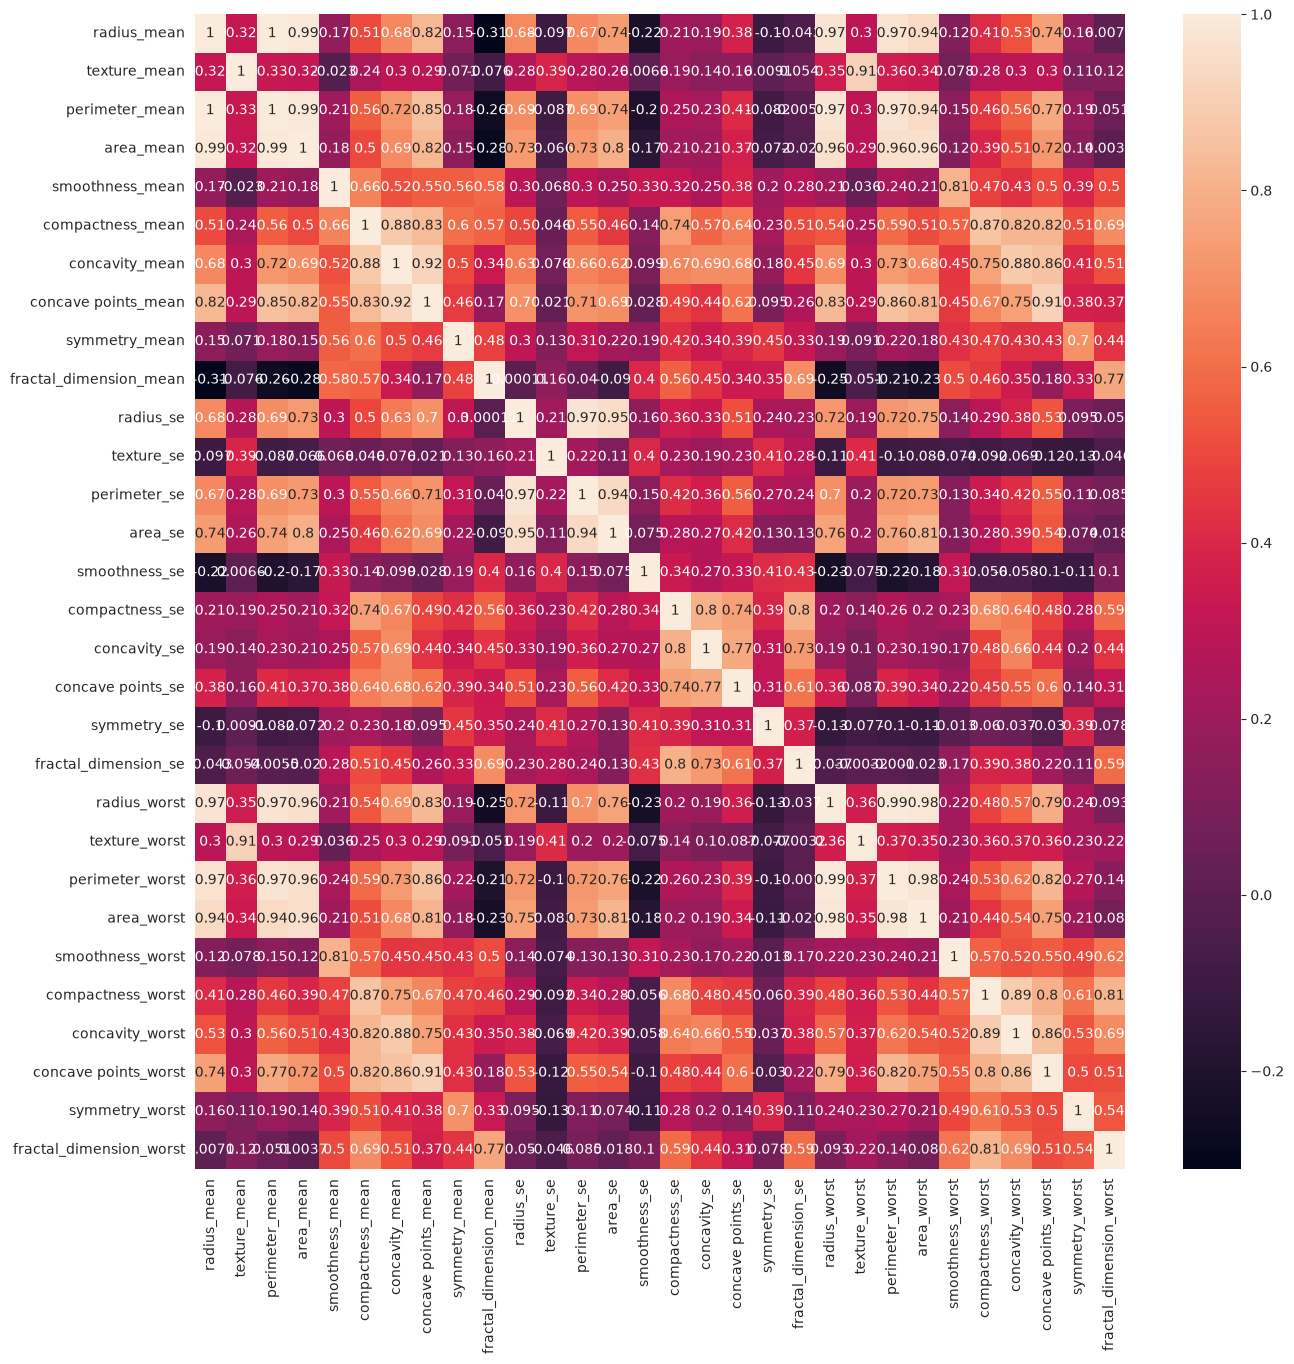

In [22]:
## correlaciones 2 a dos
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()
## ahora vemos las correlaciones mejor con un mapa de calor

## Trnansformaciones básicas

In [23]:
x = df['area_mean']
x.__class__ ## pandas series pero scikit learn no funciona bien con los pandas series. solo tiene una dimension y no se entiend bien. para tener dosdimensiones:
x = df[['area_mean']]
x.__class__ # ahora es un dataframe ## mejor siempre funcionar con doblecorchete
x = df[['area_mean', 'texture_worst']]
print(x.shape)

(569, 2)


In [24]:
## 1 variable

x = df[['area_mean']]
scaler = StandardScaler() ## instanciado pero vacio, sin meterle la variable
scaler.fit(x)
x_new = scaler.transform(x)  ## transformador: se pone transform. si es un algoritmo, se pone predict. en este caso transformador
## tamb se podria haber puesto de la siguiente formaL
x_new = scaler.fit(x).transform(x)
# o tmb:
x_new = scaler.fit_transform(x)
print(x[:2])
print(x_new[:2])
print(scaler.mean_)  ## emdia de la uncia variable que tenemos)

   area_mean
0     1001.0
1     1326.0
[[0.9843749 ]
 [1.90870825]]
[654.88910369]


In [25]:
# ahroa con minmaxscaler
scaler = MinMaxScaler()
x_new = scaler.fit_transform(x)
print(scaler.data_min_) # numero mas pequeño
print(scaler.data_max_) #numero mas grande

## podemos recuperar los valores originales:
scaler.inverse_transform(x_new)[:2] ## estos e debe a q tenemos el min y el max dentro de scaler.

[143.5]
[2501.]


array([[1001.],
       [1326.]])

In [26]:
## 2 o mas variables

x = df[['area_mean','texture_worst']]

# se hace igual
scaler = MinMaxScaler()
x_new = scaler.fit_transform(x)

## lo va  ahacer columna a columna

x_new 

array([[0.36373277, 0.14152452],
       [0.50159067, 0.30357143],
       [0.44941676, 0.36007463],
       ...,
       [0.30311771, 0.58901919],
       [0.4757158 , 0.73027719],
       [0.01590668, 0.48907249]], shape=(569, 2))

In [27]:
scaler.data_max_ ## me dice ahora los maximos de las dos columnas. funciona basicamente a nivel de columna

array([2501.  ,   49.54])

# FEature selection

In [28]:
# chi2/selectkbest

x = df.drop(columns='diagnosis')
y = df['diagnosis']
# no vamos a ahcer train rtest split ya que no vamos a entrenar ahora un modelo, solo vamos a analizar vairables 

selector = SelectKBest(score_func=chi2,k=10) # k es la cantidad de variables que nos quedamos, en este caso son 10
selector.fit(x,y)
selector.pvalues_

array([8.01397628e-060, 3.32292194e-022, 0.00000000e+000, 0.00000000e+000,
       6.98631644e-001, 2.01012999e-002, 9.00175712e-006, 1.16563638e-003,
       6.11926026e-001, 9.93122221e-001, 3.89553429e-009, 9.21168192e-001,
       1.94877489e-056, 0.00000000e+000, 9.54425121e-001, 4.33366115e-001,
       3.06726812e-001, 5.80621137e-001, 9.92847410e-001, 9.36379753e-001,
       6.11324751e-109, 7.89668299e-040, 0.00000000e+000, 0.00000000e+000,
       5.28452867e-001, 1.10836762e-005, 3.25230064e-010, 2.40424384e-004,
       2.54421307e-001, 6.30397277e-001])

In [29]:
print(pd.DataFrame(zip(x.columns, selector.pvalues_), columns=['feature', 'p_value']).sort_values('p_value', ascending=False)[:5]) # claro el malo es fratar:dimension_mean ya que es 0.99. vamos a poner los 5 primeros malos

## ahora vemos los buenos
print(pd.DataFrame(zip(x.columns, selector.pvalues_), columns=['feature', 'p_value']).sort_values('p_value', ascending=True)[:5])
# desde el punto de vista unidimensional tenemos aqui las mejores. ahora se deberia de revisar con las graficas de arriba a ver si realmente es correcto

                   feature   p_value
9   fractal_dimension_mean  0.993122
18             symmetry_se  0.992847
14           smoothness_se  0.954425
19    fractal_dimension_se  0.936380
11              texture_se  0.921168
            feature  p_value
3         area_mean      0.0
2    perimeter_mean      0.0
13          area_se      0.0
22  perimeter_worst      0.0
23       area_worst      0.0


In [30]:
print(x.shape) # 30 features
x_new = selector.transform(x) # quiero que de les 30 que saque, me aclule los chi cuadrado me encuentres los 10 mejores y me los ponga aqui
print(x_new.shape) # efectibamente las 10 mejores

(569, 30)
(569, 10)


## PCA

In [31]:
# pca
print(x.shape)
pca = PCA(n_components=11) ## quedate con 11 componenetes
pca.fit(x) # no hace falta meter la y
pca.explained_variance_ratio_
# Con la regla del codo nos quedamos con la primera, pero podriamos coger absolutamente todas. lo que pasa q las ultimas son un pco residuales, peroq ue sean residuales no significa que no aporte al modelo, al mejor nos la mejora


(569, 30)


array([9.82044672e-01, 1.61764899e-02, 1.55751075e-03, 1.20931964e-04,
       8.82724536e-05, 6.64883951e-06, 4.01713682e-06, 8.22017197e-07,
       3.44135279e-07, 1.86018721e-07, 6.99473206e-08])

In [32]:
print(x.shape)
x_new = pca.transform(x)
print(x_new.shape)

(569, 30)
(569, 11)


In [33]:
# Ejercicio. modelo que lleve minmaxscaler, que lleve un chicuadrado con 10 elementos y luego una regresion logistica

seed = 123
#######################################################3 lo que ha hecho el profesor#################################################
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2, random_state=seed)

scaler = MinMaxScaler()
selector = SelectKBest(score_func=chi2,k=10)
alg = LogisticRegression(random_state=seed)

model = make_pipeline(scaler, selector, alg)
model.fit(x_train, y_train)
print(model.score(x_test, y_test))

##################################################################################################################################3

0.9473684210526315


In [34]:
model.steps[-1][1].n_features_in_

10

In [35]:
# probamos con pca:
scaler = MinMaxScaler()
selector = SelectKBest(score_func=chi2,k=10)
alg = LogisticRegression(random_state=seed)

model = make_pipeline(scaler, selector, alg)
model.fit(x_train, y_train)
acc = model.score(x_test, y_test)
print(f"acc con chi2 {acc} ")

scaler = MinMaxScaler()
pca = PCA(n_components=10)
alg = LogisticRegression(random_state=seed)

model = make_pipeline(scaler, pca, alg)
model.fit(x_train, y_train)
acc_pca = model.score(x_test, y_test)
print(f"acc con pca {acc_pca} ") # ha aumentado un poco lol
# apra ver cual es mejor es probando xd aqui vemos que seria mejor pca

acc con chi2 0.9473684210526315 
acc con pca 0.9649122807017544 


In [36]:
## ya que estamos, probamos todo, poniendo todas las cantidades de variables y demas...

for ii in range (1,30):
    scaler = MinMaxScaler()
    selector = SelectKBest(score_func=chi2,k=ii)
    alg = LogisticRegression(random_state=seed)

    model = make_pipeline(scaler, selector, alg)
    model.fit(x_train, y_train)
    acc = model.score(x_test, y_test)
    print(f"{ii} acc con chi2 {acc} ")

    scaler = MinMaxScaler()
    pca = PCA(n_components=ii)
    alg = LogisticRegression(random_state=seed)

    model = make_pipeline(scaler, pca, alg)
    model.fit(x_train, y_train)
    acc_pca = model.score(x_test, y_test)
    print(f"{ii} acc con pca {acc_pca} ")


    ## arece que va ganando la pca, con pocas features. si queremos quedarnos solo con pca, pues tiramos a full con pca y eliminamos chi2

1 acc con chi2 0.8947368421052632 
1 acc con pca 0.9473684210526315 
2 acc con chi2 0.9385964912280702 
2 acc con pca 0.9649122807017544 
3 acc con chi2 0.9298245614035088 
3 acc con pca 0.9649122807017544 
4 acc con chi2 0.9473684210526315 
4 acc con pca 0.9649122807017544 
5 acc con chi2 0.956140350877193 
5 acc con pca 0.9649122807017544 
6 acc con chi2 0.956140350877193 
6 acc con pca 0.9649122807017544 
7 acc con chi2 0.956140350877193 
7 acc con pca 0.9649122807017544 
8 acc con chi2 0.956140350877193 
8 acc con pca 0.9649122807017544 
9 acc con chi2 0.956140350877193 
9 acc con pca 0.9649122807017544 
10 acc con chi2 0.9473684210526315 
10 acc con pca 0.9649122807017544 
11 acc con chi2 0.956140350877193 
11 acc con pca 0.9649122807017544 
12 acc con chi2 0.956140350877193 
12 acc con pca 0.9649122807017544 
13 acc con chi2 0.956140350877193 
13 acc con pca 0.9649122807017544 
14 acc con chi2 0.956140350877193 
14 acc con pca 0.9649122807017544 
15 acc con chi2 0.956140350877193

## vamos con RFE

In [37]:
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

model = LogisticRegression()
rfe = RFE(estimator=model, n_features_to_select=9)
rfe.fit(x,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",9
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[object](2,)","['B','M']"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LogisticRegression,LogisticRegression()
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(9)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,30


In [38]:
rfe.ranking_

array([ 1, 13, 17, 20, 12,  5,  1,  1, 10, 19,  1,  2,  1,  7, 22,  6, 14,
       15, 18, 21, 11,  3,  4, 16,  9,  1,  1,  1,  1,  8])

In [39]:
print(x.shape)
x_new = rfe.transform(x)
print(x_new.shape) ## efectivamente se queda solo con 9

(569, 30)
(569, 9)


## feature importances

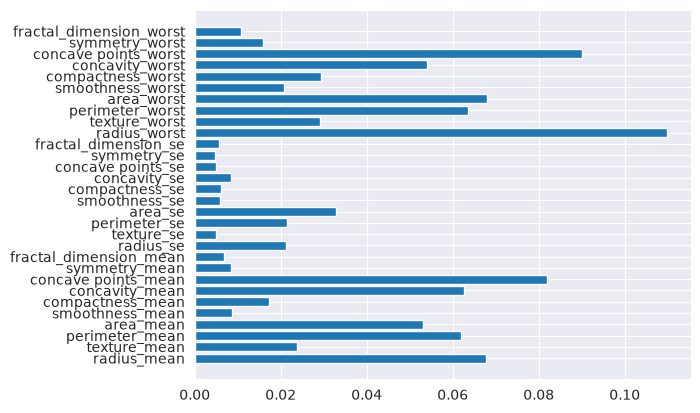

In [40]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier()
model.fit(x,y)
model.feature_importances_ ## nos dice cuanta improtancia tienen las features (seria mejor ordenarlas)
## vamos a verlo con un plot
plt.barh(y =x.columns, width=model.feature_importances_)
plt.show() # vemos las improtancias de las variables

In [41]:
alg = LogisticRegression()
scaler = MinMaxScaler()
model = make_pipeline(scaler,alg)
model.fit(x,y)
model.steps[-1][1].coef_[0]
# model.coef_[0] # tenemos los positivos y los negativos 


array([ 1.89245287,  1.7164987 ,  1.85683898,  1.60897612,  0.64627197,
        0.33322584,  1.43774434,  2.14350113,  0.54801534, -0.98139832,
        1.29174989,  0.03265637,  0.99370891,  0.85501125,  0.06845565,
       -0.6570181 , -0.2720521 ,  0.26522948, -0.23091012, -0.63212283,
        2.43833645,  2.35873461,  2.2277386 ,  1.76845038,  1.57859088,
        0.7790283 ,  1.38070971,  2.72399651,  1.34480224,  0.34473524])

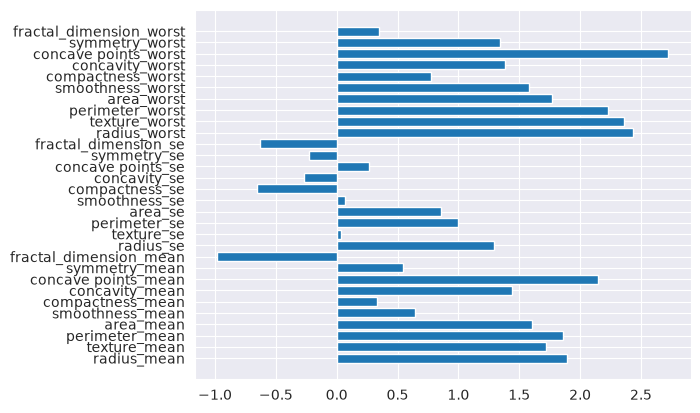

In [42]:
## vamos a ahcer ahora un plot
plt.barh(y=x.columns, width=model.steps[-1][1].coef_[0])
plt.show()

## corss validation

In [43]:
from sklearn.model_selection import KFold, ShuffleSplit
from sklearn.model_selection import cross_val_predict, cross_val_score

cv_technique = KFold(n_splits=5)
model = LogisticRegression(random_state=99)
cross_val_score(model,x,y, cv=cv_technique) # me ha hehco las 45 métricas. con un corte me ha dado 0.91, en otro 0.93, y asi sucesivamente. es bastante robusto. todos los resultados estan mas o menos en la misma region. Salta de 0.91 a 0.973
# pero si salta de 0.95 a 0.85 empezaria a mosquear un pco. pero esto es una regresion logistica, a lo mejor otros modelos me hacen otra cosas

cv_technique = KFold(n_splits=5, shuffle=True, random_state=99)
model = LogisticRegression(random_state=99)
results = cross_val_score(model,x,y, cv=cv_technique)
## sigue siendo robusto
results.mean()

np.float64(0.943766495885732)

In [44]:
# ahroa con validacion cruzada
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
seed = 67
models = []
models.append(('lr',LogisticRegression()))
models.append(('dtc',DecisionTreeClassifier()))
models.append(('nb',GaussianNB()))
models.append(('knn',KNeighborsClassifier()))
models.append(('lda',LinearDiscriminantAnalysis()))
models.append(('rf',RandomForestClassifier()))
models.append(('svm',SVC()))

In [45]:
# vamos a ver si son modelso robustos o no

cv_technique = KFold(n_splits=5, shuffle=True, random_state=seed)

names = []
results = []
for name , model in models:
    cv_results = cross_val_score(model,x,y,cv=cv_technique)

    names.append(name)
    results.append(cv_results)

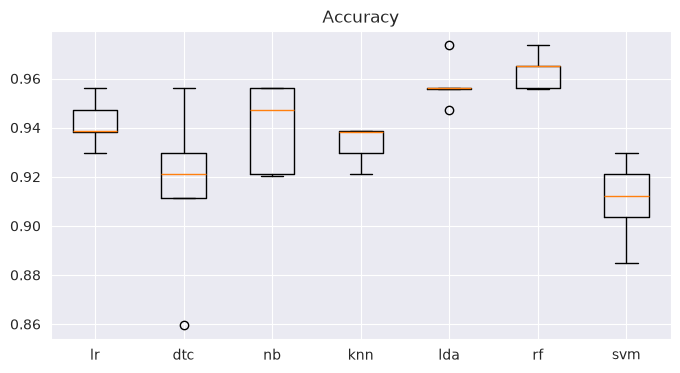

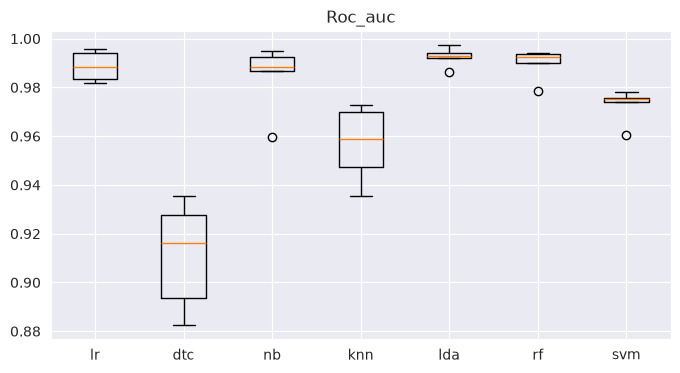

In [46]:
results ## vemos que hay 5 validaciones por cada uno de los modelos. vamos a ahcer un dibujo para verlo mejor
plt.figure(figsize=(8,4))
plt.title('Accuracy')
plt.boxplot(results)
plt.xticks(range(1,len(names)+ 1),names)
plt.show()

## aqui es cuando descartamos modelos o los cogemos
# con este boxplot podemos ver mucha informacion
# el mejor modelo asi de pronto es estudaindlos a dos

## aqui vemos que le mejor modelo es el random fores. el 50% de las veces da el valor mas alto que caulquier otro, el valor mas bajo, es el mismo que el 50% de las veces que el lda. y puede llegar a tener un valor igual de alto q algun punto del lda. 

## una cosa importante es q estamos trabajndo con accuracy, por lo tanto estamos evaluando el modelo segun accuracy. si necesitasemos otro parametro o modelo de medicion, tendiramos que hacerlo de otra forma. POr ejemplo, para asegurarnos los modelos, vemos otra metrica:
# vamos a ver si son modelso robustos o no

cv_technique = KFold(n_splits=5, shuffle=True, random_state=seed)

names = []
results = []
for name , model in models:
    cv_results = cross_val_score(model,x,y,cv=cv_technique,scoring='roc_auc')

    names.append(name)
    results.append(cv_results)

results ## vemos que hay 5 validaciones por cada uno de los modelos. vamos a ahcer un dibujo para verlo mejor
plt.figure(figsize=(8,4))
plt.title('Roc_auc')
plt.boxplot(results)
plt.xticks(range(1,len(names)+ 1),names)
plt.show()

In [47]:
cross_val_predict(model,x,y,cv=cv_technique) # aqui nos sacan las predicciontes preomdedios de las 5 splits q hay

array(['M', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M',
       'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'B', 'M', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

# Metricas

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

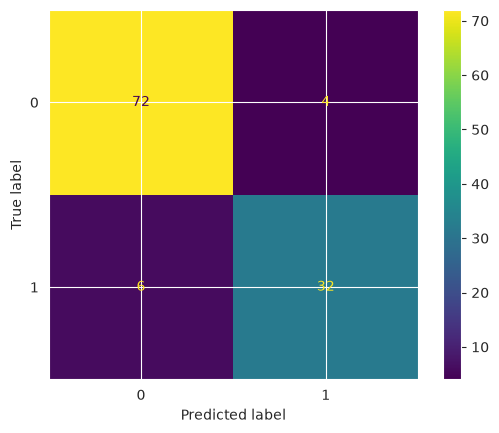

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=99)

model = DecisionTreeClassifier(random_state=99)
model.fit(x_train,y_train)
y_hat = model.predict(x_test)
## hay q comparar y_hat que es la que estamos prediciendo con y_test, para la matriz de confusion
# a psera de  uno sea pandas serie sy otr un array, no pasa nada, ma matriz de confusion lo hace bien:

cm = confusion_matrix(y_true=y_test,y_pred=y_hat)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
accuracy_score(y_true=y_test,y_pred=y_hat) # para el accuracy

0.9122807017543859

# tuneando modelos

In [55]:
from sklearn.model_selection import GridSearchCV

seed =99
model = DecisionTreeClassifier(random_state=seed)
cv_technique = KFold(n_splits=10, shuffle=True,random_state=seed)
params = {
    'criterion': ['gini','entropy','log_loss'],
    'max_depth': [3,6,12,50],
    'max_features': [3,6,15,25]
} ## parametros que queiro que pruebe el gridserach para encontrar el mejor modelo

grid_model = GridSearchCV(
    estimator=model,
    cv=cv_technique,
    param_grid=params,
    scoring='accuracy'
)

grid_model.fit(x,y) ## como antes de hacer el kfold antes del grid yu lo estamos diviendo no tendriamos porq hacer una division de train y split, pero en otro caso si se deberia hacer. de todos modos, no es muy recomendable, ya que el conjunto de test esta entrando en el conjunto de entrenamiento

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 6, ...], 'max_features': [3, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [ ]:
grid_model.best_estimator_ ## mejor modelo con los parametros de entrada

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",99
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [ ]:
grid_model.best_score_ ## best score de media (ha hecho los 10 splits y es la media de los 10 splits)

np.float64(0.9454260651629072)

In [59]:
grid_model.cv_results_

{'mean_fit_time': array([0.00698545, 0.00592997, 0.00814281, 0.00911319, 0.0086535 ,
        0.00799747, 0.00950625, 0.01224351, 0.0061867 , 0.00730009,
        0.00926108, 0.01500351, 0.00929372, 0.00709324, 0.00993915,
        0.01159463, 0.00589163, 0.00651765, 0.00774622, 0.01020157,
        0.00610194, 0.00747526, 0.01095412, 0.01186523, 0.00615816,
        0.00810373, 0.00933206, 0.01206915, 0.00584795, 0.00675747,
        0.00900629, 0.0122225 , 0.00560045, 0.00635931, 0.00792611,
        0.01086352, 0.00617111, 0.00706687, 0.00943859, 0.01211863,
        0.00631993, 0.00765026, 0.0111083 , 0.01285503, 0.00589435,
        0.00818088, 0.01021385, 0.01231208]),
 'std_fit_time': array([0.00276049, 0.00046157, 0.00105118, 0.00105734, 0.00121713,
        0.00138429, 0.00040816, 0.00130012, 0.00068646, 0.00113244,
        0.00043242, 0.00384832, 0.0015481 , 0.00059939, 0.00070397,
        0.00071439, 0.00072646, 0.00047135, 0.00026727, 0.0006374 ,
        0.00042136, 0.00074293, 0.002

In [60]:
## !! overfitting

x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=seed)

odel = DecisionTreeClassifier(random_state=seed)
cv_technique = KFold(n_splits=10, shuffle=True,random_state=seed)
params = {
    'criterion': ['gini','entropy','log_loss'],
    'max_depth': [3,6,12,50],
    'max_features': [3,6,15,25]
} ## parametros que queiro que pruebe el gridserach para encontrar el mejor modelo

grid_model = GridSearchCV(
    estimator=model,
    cv=cv_technique,
    param_grid=params,
    scoring='accuracy'
)

grid_model.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 6, ...], 'max_features': [3, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [ ]:
print(grid_model.best_score_)
print(grid_model.best_estimator_) ## apreceia robusto antes con lo cual nos podriamos fiar

0.947391304347826
DecisionTreeClassifier(criterion='entropy', max_depth=12, max_features=15,
                       random_state=99)


In [64]:
print(grid_model.best_estimator_.__class__) ## este es nuestro modelo final y lompdoemos exportar en pickle o lo q sea
best_model = grid_model.best_estimator_
y_hat = best_model.predict(x_test)
accuracy_score(y_true=y_test, y_pred=y_hat)

<class 'sklearn.tree._classes.DecisionTreeClassifier'>


0.9035087719298246